In [3]:
import pandas as pd
import matplotlib.pyplot as plt

1. Consumo di alcol per paese

Esegui un’analisi esplorativa focalizzata sul consumo di alcol.

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

print(df)

         country  beer_servings  spirit_servings  wine_servings  \
0    Afghanistan              0                0              0   
1        Albania             89              132             54   
2        Algeria             25                0             14   
3        Andorra            245              138            312   
4         Angola            217               57             45   
..           ...            ...              ...            ...   
188    Venezuela            333              100              3   
189      Vietnam            111                2              1   
190        Yemen              6                0              0   
191       Zambia             32               19              4   
192     Zimbabwe             64               18              4   

     total_litres_of_pure_alcohol  
0                             0.0  
1                             4.9  
2                             0.7  
3                            12.4  
4              

1.1 Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

In [5]:
df_ordered = df.sort_values(by = "total_litres_of_pure_alcohol", ascending=False)

print(df_ordered.head(10))

                country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
61               France            127              151            370   
45       Czech Republic            361              170            134   
141  Russian Federation            247              326             73   
99           Luxembourg            236              133            271   
155            Slovakia            196              293            116   
81              Ireland            313              118            165   

     total_litres_of_pure_alcohol  
15                           14.4  
98                           12.9  
3                            12.4  
68                           11.9  
61   

1.2 Calcola la media del consumo di birra, vino, e distillati

In [6]:
mean_beer = df['beer_servings'].mean()
mean_wine = df['wine_servings'].mean()
mean_spirit = df['spirit_servings'].mean()

print(f"Mean beer: {mean_beer} Mean wine: {mean_wine} Mean spirit: {mean_spirit}")

Mean beer: 106.16062176165804 Mean wine: 49.45077720207254 Mean spirit: 80.99481865284974


1.3 Crea una nuova colonna alcohol_index che sia: (beer_servings + wine_servings + spirit_servings) / 3

In [7]:
df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3
#print(df)

#meglio:

df['alcohol_index_improved'] = df[['beer_servings', 'wine_servings', 'spirit_servings']].mean(axis=1)
print(df)

         country  beer_servings  spirit_servings  wine_servings  \
0    Afghanistan              0                0              0   
1        Albania             89              132             54   
2        Algeria             25                0             14   
3        Andorra            245              138            312   
4         Angola            217               57             45   
..           ...            ...              ...            ...   
188    Venezuela            333              100              3   
189      Vietnam            111                2              1   
190        Yemen              6                0              0   
191       Zambia             32               19              4   
192     Zimbabwe             64               18              4   

     total_litres_of_pure_alcohol  alcohol_index  alcohol_index_improved  
0                             0.0       0.000000                0.000000  
1                             4.9      91.666

1.4 Trova il paese con il valore massimo di alcohol_index

In [8]:

print(df[df['alcohol_index'] == df['alcohol_index'].max()])

   country  beer_servings  spirit_servings  wine_servings  \
3  Andorra            245              138            312   

   total_litres_of_pure_alcohol  alcohol_index  alcohol_index_improved  
3                          12.4     231.666667              231.666667  


1.5 Filtra solo i paesi che consumano più di 100 birre all’anno

In [9]:
print(df[df['beer_servings'] > 100])

               country  beer_servings  spirit_servings  wine_servings  \
3              Andorra            245              138            312   
4               Angola            217               57             45   
5    Antigua & Barbuda            102              128             45   
6            Argentina            193               25            221   
8            Australia            261               72            212   
..                 ...            ...              ...            ...   
182     United Kingdom            219              126            195   
184                USA            249              158             84   
185            Uruguay            115               35            220   
188          Venezuela            333              100              3   
189            Vietnam            111                2              1   

     total_litres_of_pure_alcohol  alcohol_index  alcohol_index_improved  
3                            12.4     231.666667

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

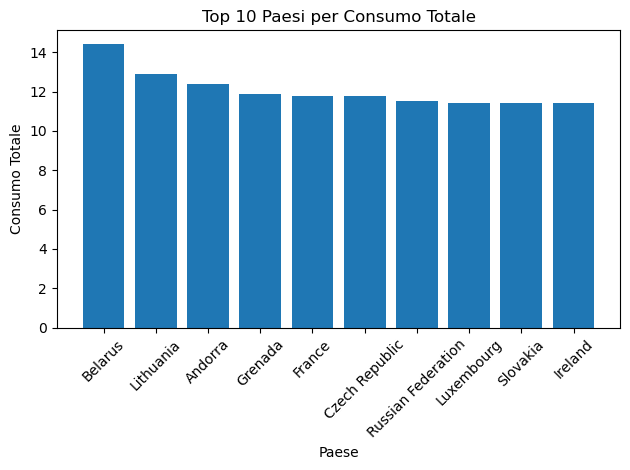

In [10]:
top10 = df_ordered.head(10)

plt.figure()
plt.bar(top10["country"], top10["total_litres_of_pure_alcohol"])

# Etichette e titolo
plt.xlabel("Paese")
plt.ylabel("Consumo Totale")
plt.title("Top 10 Paesi per Consumo Totale")

# Ruota le etichette per leggibilità
plt.xticks(rotation=45)

# Mostra il grafico
plt.tight_layout()
plt.show()

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

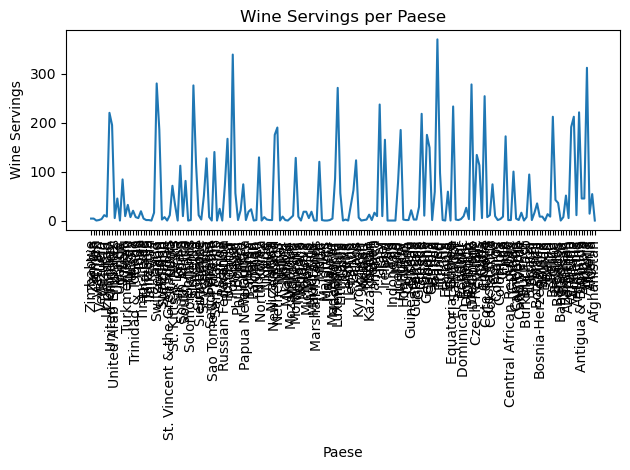

In [13]:
# Crea il line plot
df_sorted = df.sort_values("country", ascending=False)

plt.figure()
plt.plot(df_sorted["country"], df_sorted["wine_servings"])

# Etichette e titolo
plt.xlabel("Paese")
plt.ylabel("Wine Servings")
plt.title("Wine Servings per Paese")

# Ruota le etichette per leggibilità
plt.xticks(rotation=90)

# Layout migliore
plt.tight_layout()

# Mostra il grafico
plt.show()